# 04 · Capabilities Showcase — the Full Demo, in a Notebook

Notebooks `01`–`03` explained *how* the graph is built. This one shows *what it
can do* — the complete range of value the live demo delivers, reproduced through
the notebook interface. Every query below is lifted straight from the demo script
(`SAMPLE_QUERIES_SYNTHETIC_DATA.txt`) and run against the real agent, with answers
and **datasheet/photo images rendered inline** so you get the same payoff you'd
see in the React UI.

| # | Capability | Query type | What's special |
|---|---|---|---|
| 1 | Catalog discovery | single specialist | exhaustive spec filter, guaranteed complete |
| 2 | EOL check → find → score | 3-specialist chain + live web | the headline flow; Opus synthesizes |
| 3 | Text query → **visual** | Knowledge | a torque-curve datasheet renders inline |
| 4 | **Image in** → full pipeline | multimodal | upload a chart, identify the part, then score + compare |
| 5 | Draft a substitution memo | Evaluation | a formal, signable PSJ document |
| 6 | Visual similarity | Nova MME + Claude Vision | quantitative score + physical-difference analysis |
| 7 | Free exploration | all specialists | the full query menu by specialist |

> **What you need.** Sections 1–4 and 7 make live Bedrock calls (Claude Haiku /
> Sonnet / Opus 5.5). Section 4's image-as-query and section 6's visual score also
> need Nova MME, a configured `PARTS_KB_ID`, and the S3 Vectors index. Section 5
> (memo) is **fully local — no Bedrock needed**. Each section says what it requires.

> The engineer decides; the system assembles evidence. Nothing here recommends or
> approves a substitution.

## 0 · Setup + a reusable streaming renderer

The helper below runs the **real** chat orchestration
(`run_agent_with_events` from `api/services/stream_adapter.py`) and renders the
result the way the UI does: the routing chain, the final synthesized answer as
**Markdown**, and any part images **inline**. This is the single tool we reuse for
every chat query in this notebook.

In [1]:
import os, sys, json, threading, base64
from queue import Queue, Empty
from pathlib import Path
from IPython.display import display, Markdown, Image, HTML

# Standalone: use the vendored mei_core package + bundled data in this folder.
# No dependency on the parent app's agent/ or api/ — this folder is portable.
NB_DIR = Path.cwd() if (Path.cwd() / 'mei_core').exists() else Path.cwd() / 'notebooks'
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))
REPO_ROOT = NB_DIR  # alias: bundled demo-crops/ and evals/ live under NB_DIR
_bundled = NB_DIR / 'data' / 'synthetic-parts-data'
if _bundled.exists():
    os.environ['PARTS_DATA_DIR'] = str(_bundled)

os.environ.setdefault('DATASET', 'synthetic')
os.environ.setdefault('BEDROCK_REGION', 'us-east-1')

from mei_core import dataset_profiles
PROFILE = dataset_profiles.resolve()
from mei_core.tools import PARTS_DATA_DIR
print('dataset   :', PROFILE['DATASET'])
print('catalog   :', PROFILE['PARTS_DATA_DIR'])
print('KB id     :', PROFILE['PARTS_KB_ID'] or '(none — local demo mode)')
print('gateway   :', os.environ.get('AGENTCORE_GATEWAY_ID', '(none)'))

dataset   : synthetic
catalog   : /Users/agavili/Desktop/SkyLab-ManufacturingIntelligence/notebooks/data/synthetic-parts-data
KB id     : KBJSEK4HDV
gateway   : (none)


In [2]:
from mei_core.stream_adapter import run_agent_with_events

def ask(user_input, image_b64=None, show_route=True, show_images=True, timeout=240):
    """Run a chat query through the real multi-agent orchestration and render
    the result inline: routing chain, final Markdown answer, and part images.
    Returns the final answer text."""
    q = Queue()
    t = threading.Thread(target=run_agent_with_events,
                         args=(user_input, image_b64, q), daemon=True)
    t.start()

    route, final_text, images, errors = [], '', [], []
    content_by_specialist = {}
    while True:
        try:
            evt = q.get(timeout=timeout)
        except Empty:
            errors.append('timed out waiting for events')
            break
        name, data = evt['event'], evt['data']
        if name == 'routing':
            route = data['specialists']
        elif name == 'content':
            content_by_specialist[data['specialist']] = data['text']
        elif name == 'synthesis':
            final_text = data['text']
        elif name == 'images':
            images = data['images']
        elif name == 'error':
            errors.append(str(data))
        elif name == 'done':
            break
    t.join(timeout=5)

    # Single-specialist turns emit no 'synthesis' event — use the specialist text.
    if not final_text and content_by_specialist:
        final_text = list(content_by_specialist.values())[-1]

    if show_route and route:
        chain = '  →  '.join(s.upper() for s in route)
        display(Markdown(f'**Routing:** {chain}'))
    if errors:
        display(Markdown('**Errors:** ' + '; '.join(errors)))
    display(Markdown(final_text or '*(no answer)*'))
    if show_images and images:
        for img in images:
            local = Path(PARTS_DATA_DIR) / img['part_id'] / img['filename']
            display(Markdown(f"*{img['part_id']} / {img['filename']}*"))
            if local.exists():
                display(Image(filename=str(local), width=520))
            else:
                display(Markdown(f'`{local}` (not found locally)'))
    return final_text

print('ask() ready')

ask() ready


---
## 1 · Catalog discovery (single specialist)

*Demo Query 1.* A plain discovery question. The planner routes to **Catalog**
alone, which uses the exhaustive `filter_parts_by_spec` scan — so the answer is
guaranteed complete, not a top-K guess. Because only one specialist runs, there's
no Opus synthesis step.

_Requires: Bedrock (Haiku + Sonnet)._

In [3]:
_ = ask('Which AnyCompany wheels are compatible with a 5V bus?')
# Expected: RW 0.01 and RW 0.03 (the two 5V parts).

1. CATALOG — discover AnyCompany wheels with 5V bus compatibility

**Routing:** CATALOG

Three AnyCompany reaction wheels can run on a 5 V bus. The catalog lists AnyCompany as the vendor for all three, and all three are Active and in full production. The exhaustive scan covered 7 parts.

| Part ID | Name | Nominal V | Supply range | Momentum | Max torque | Interface | Mass | Power |
|---|---|---|---|---|---|---|---|---|
| **rw_rl_0010** | AnyCompany RW 0.01 | 5 V | 3.5–6.0 V | 0.01 Nms | 1.0 mNm | ASYNC | 125 g | 0.2 W |
| **rw_rl_0030** | AnyCompany RW 0.03 | 5 V | 3.5–6.0 V | 0.03 Nms | 1.5 mNm | ASYNC | 185 g | 0.2 W |
| **rw_rl_0003** | AnyCompany RW 0.003 | 7 V | 5–8.8 V | 0.003 Nms | 1.5 mNm | I2C or ASYNC | 50 g | not listed |

- **RW 0.01 and RW 0.03:** These are the natural fits because 5 V is their nominal supply. The 3.5–6.0 V range leaves margin on both sides of 5 V. The datasheet performance curves for both are given at 5 V in vacuum. Both have 10+ years estimated to end of life, and lead times are 12 weeks for the RW 0.01 and 10 weeks for the RW 0.03. The two share a common design.
- **RW 0.003:** It is only marginally compatible. Its nominal supply is 7 V, and 5 V is the very bottom of its 5–8.8 V range, so there is no undervoltage margin. Its datasheet shows about 1.5× less torque at 5 V than at 7 V. Check that your 5 V bus never sags below 5 V before you consider it. It has 8+ years estimated to end of life and a 14-week lead time (medium risk).
- **Not compatible:** AnyCompany RW 5.0 (rw_rl_5000) is the only other AnyCompany wheel in the results. It needs 22–34 V (28 V nominal).

If you give me your momentum, torque, interface, and temperature requirements, I can narrow this down further.

A few more discovery questions from the demo menu — each is one Catalog turn:

In [4]:
_ = ask('What are the lightest wheels in the catalog?')

1. CATALOG — discover wheels in the catalog and rank them by weight

**Routing:** CATALOG

The catalog has 7 reaction wheels. The exhaustive scan covered all of them, and they are all from AnyCompany. Here they are from lightest to heaviest:

| Rank | Part ID | Name | Mass (g) | Momentum (N·m·s) | Supply voltage (V) | Interface | Lifecycle |
|---|---|---|---|---|---|---|---|
| 1 | rw_rl_0003 | AnyCompany RW 0.003 | 50 | 0.003 | 5 to 8.8 | I2C or ASYNC | Active |
| 2 | rw_rl_0010 | AnyCompany RW 0.01 | 125 | 0.01 | 3.5 to 6.0 | ASYNC | Active |
| 3 | rw_rl_0030 | AnyCompany RW 0.03 | 185 | 0.03 | 3.5 to 6.0 | ASYNC | Active |
| 4 | rw_rl_0060 | AnyCompany RW3 0.06 | 235 | 0.06 | 7.5 to 36 | RS-422 or redundant RS-485 | Active |
| 5 | rw_rl_0400 | AnyCompany RW4 0.4 | 755 | 0.4 | 22 to 34 | not retrieved | not retrieved |
| 6 | rw_rl_1000 | AnyCompany RW4 1.0 | 1400 | 1.0 | 22 to 34 | RS-422 or redundant RS-485 | Active |
| 7 | rw_rl_5000 | AnyCompany RW 5.0 | 3000 | 5.0 | 22 to 34 | not retrieved | not retrieved |

**The lightest is rw_rl_0003 (AnyCompany RW 0.003), at 50 g.** The datasheet lists its mass as "<50 g", so the catalog's 50 g is an upper bound.
- **Size:** 33.5 × 33.5 × 17 mm.
- **Torque:** ±1.5 mN·m.
- **Radiation tolerance:** 19.5 krad.
- **Lead time:** 14 weeks, rated medium lead-time risk.
- **Heritage:** 21 units with 30+ cumulative years since 2023. It's the newest design and has the least flight history.
- **Demand trend:** increasing.

**The second lightest is rw_rl_0010 (AnyCompany RW 0.01), at 125 g.**
- **Size:** 50 × 50 × 29.5 mm.
- **Torque:** ±1.0 mN·m.
- **Heritage:** 12 units with 105+ cumulative years.
- **Lead time:** 12 weeks, rated low risk.

**Trade-off:** mass rises with momentum capacity. If you need more momentum than 0.003 N·m·s, the next lightest options are rw_rl_0010 and rw_rl_0030. rw_rl_0030 has the most heritage of the small wheels, with 90 units and 510+ years.

I didn't retrieve the interface or lifecycle status for rw_rl_0400 and rw_rl_5000. I can pull their full specs if you want them.

In [5]:
_ = ask('Show me all wheels with radiation tolerance above 30 krad.')

1. CATALOG — find all wheels with radiation tolerance above 30 krad

**Routing:** CATALOG

Three of the 7 reaction wheels in the catalog have a radiation tolerance above 30 krad. I checked all 7 with an exhaustive filter, so this list is complete. All three are rated 50 krad.

| Part ID | Name | Vendor | Momentum (Nms) | Max torque (mNm) | Mass (g) | Supply voltage (V) | Interface | Power (W) | Lifecycle |
|---|---|---|---|---|---|---|---|---|---|
| rw_rl_0400 | AnyCompany RW4 0.4 | AnyCompany | 0.4 | 100 | 755 | 28 (range 22–34) | RS-422 or redundant RS-485 | 2.8 | Active, full production, 8+ years to EOL |
| rw_rl_1000 | AnyCompany RW4 1.0 | AnyCompany | 1.0 | 100 | 1400 | 28 (range 22–34) | RS-422 or redundant RS-485 | 5 | Active, full production, 10+ years to EOL |
| rw_rl_5000 | AnyCompany RW 5.0 | AnyCompany | 5.0 | 150 | 3000 | 28 (range 22–34) | RS-422 or redundant RS-485 | 20 | Active, full production, 10+ years to EOL |

- **Lead times:** The 0.4 and 1.0 Nms wheels are 12 weeks with low risk. The 5.0 Nms wheel is 16 weeks with medium risk.
- **Heritage:** The 5.0 Nms wheel had its first flights in 2026. The 1.0 Nms wheel is the most mature of the three, with 144 units and 670+ years since 2016. The 0.4 Nms wheel is newer, with 28 units and 50+ years since 2023.

The other four wheels fall below the threshold:

| Part ID | Radiation tolerance (krad) |
|---|---|
| rw_rl_0030 | 24 |
| rw_rl_0010 | 24 |
| rw_rl_0060 | 20 |
| rw_rl_0003 | 19.5 |

I can compare any of the three against your momentum, voltage or interface requirements if that helps.

---
## 2 · The headline flow: EOL check → find alternatives → score

*Demo Query 2.* This is the money shot. One sentence from the engineer triggers a
**three-specialist chain**:

1. **Knowledge** checks current market/EOL status (live web search via the Gateway
   when configured, simulated otherwise).
2. **Catalog** finds alternatives that fit the interface/bus.
3. **Evaluation** scores each candidate against the momentum requirement.

Because 2+ specialists ran, the **Opus supervisor** merges them into one answer.
This makes several sequential Bedrock calls — expect 60–140 seconds.

_Requires: Bedrock (Haiku + Sonnet + Opus). Live web needs `AGENTCORE_GATEWAY_ID`;
otherwise the EOL step uses simulated market data._

In [6]:
_ = ask(
    'The RW3 0.06 might be approaching end-of-life. Check its current market '
    'status, then find me alternatives for a 28V RS-422 CubeSat and score them '
    'against 0.06 Nms minimum momentum.',
    timeout=240,
)

1. KNOWLEDGE — check current market status of RW3 0.06 for end-of-life
2. CATALOG — find 28V RS-422 reaction wheel alternatives
3. EVALUATION — score candidates against 0.06 Nms minimum momentum

**Routing:** KNOWLEDGE  →  CATALOG  →  EVALUATION

**Errors:** {'specialist': 'system', 'message': 'An error occurred (ServiceUnavailableException) when calling the ConverseStream operation (reached max retries: 4): Bedrock is unable to process your request.'}

## Spec-fit scoring: RW3 0.06 (reference) vs. alternatives

The vendor for all four parts is **AnyCompany**. The requirements were ≥0.06 Nms, 28 V and RS-422. No operating temperature range was supplied, so the tool compared against the reference's range of −30 to +70 °C.

| Spec | Rule | RW3 0.06 (ref) | RW4 0.4 | RW4 1.0 | RW 5.0 |
|---|---|---|---|---|---|
| Momentum (Nms) | ≥ 0.06 | 0.06 | 0.4 ✔ | 1.0 ✔ | 5.0 ✔ |
| Bus voltage | match 28 V | 28 | 28 ✔ | 28 ✔ | 28 ✔ |
| Interface | match RS-422 | RS-422 or redundant RS-485 | ✔ | ✔ | ✔ |
| Operating temp (°C) | envelops range | −30 to +70 | −30 to +70 ✔ | −30 to +70 ✔ | −30 to +70 ✔ |
| Max torque (mNm) | ≥ ref | 20 | 100 ✔ | 100 ✔ | 150 ✔ |
| **Mass (g)** | ≤ ref +20% (282 g) | 235 | **755 ⚠ FLAG** | **1400 ⚠ FLAG** | **3000 ⚠ FLAG** |
| Radiation (krad) | ≥ ref | 20 | 50 ✔ | 50 ✔ | 50 ✔ |
| Qualification | same standard | AnyCompany internal (flight heritage) | same ✔ | same ✔ | same ✔ |
| **Tool result** | | | 7 pass, 1 flag | 7 pass, 1 flag | 7 pass, 1 flag |

**Flags**
- **Mass:** All three candidates exceed the +20% limit by a wide margin. The tool's summary for each is "Not a drop-in replacement; flagged specs require engineering review."
  - RW4 0.4: 755 g (about 3.2× the reference).
  - RW4 1.0: 1400 g (about 6×).
  - RW 5.0: 3000 g (about 12.8×).
- **Operating temperature:** The tool listed this as a missing input. The pass result only shows the candidates match the reference range. The prior specialist also noted a datasheet discrepancy for the RW3 0.06: −30 to +60 °C on the datasheet against +70 °C in the catalog. Please confirm your required range.

**Lifecycle and supply chain**
- All three candidates and the reference are Active, and the tool raised no lifecycle flags.
- Lead times for the candidates are 12 weeks (RW4 0.4), 12 weeks (RW4 1.0) and 16 weeks (RW 5.0). The catalog specialist rated the RW 5.0 lead-time risk as Medium.
- Heritage, from the prior catalog results, is limited for the RW4 0.4 (28 units) and the RW 5.0 (first flights 2026).

**Supplemental: Visual Analysis (RW3 0.06 vs. RW4 0.4, the closest candidate by mass)**
- Nova MME similarity is **0.686**, which the tool interprets as "visually different form factors." This is a supplemental signal only.
- The RW3 has a square black frame with four corner mounting holes. The RW4 0.4 is a circular ring-shaped assembly with a circular bolt pattern on the flange.
- The tool's analysis is that the two could not share the same bracket and would need a new mounting interface.
- Neither photo has a scale reference, and no electrical connector was clearly visible on either unit.

**Other notes**
- The RW 0.03 and RW 0.01 were screened out earlier on voltage (5 V), interface (ASYNC) and momentum. I did not re-score them.
- The catalog covers AnyCompany wheels only.

*Disclaimer: This is evidence only. It is not a recommendation or approval of any substitution. The engineer decides.*

---
## 3 · A text question that returns a **visual**

*Demo Query 3.* The engineer asks in words; the system answers with a **picture**.
The chat layer resolves the named part deterministically (by its unique momentum
value) and renders that part's datasheet page — specifically the cropped chart
band — inline. The `ask()` helper displays it below the answer.

_Requires: Bedrock. The inline chart renders from the local catalog; a configured
KB improves the Knowledge specialist's narrative._

1. KNOWLEDGE — retrieve torque curve data for the RW3 0.06 from datasheet/ICD

**Routing:** KNOWLEDGE

**AnyCompany RW3-0.06** (catalog ID `rw_rl_0060`): the datasheet page has two torque graphs. The search returned text descriptions of them, not the image files. The source is `datasheet_page.png`: https://skylab-manufacturing.s3.amazonaws.com/synthetic-parts-data/rw_rl_0060/datasheet_page.png

- **Torque box (left graph):** Momentum runs from -0.06 to +0.06 Nms on the x-axis and torque from -0.02 to +0.02 Nm on the y-axis. The envelope is a rectangle with flat top and angled sides, and the continuous rating is marked. It shows about ±20 mNm available across the momentum range, which matches the catalog's max torque of 20 mNm.
- **Torque curve (right graph, vacuum, 28 V):** Momentum runs from -0.06 to +0.06 Nms on the x-axis and current from 0 to 0.14 A on the y-axis. There are separate colored curves for different speeds (gray is 1 rpm/min and orange is 2 rpm/min). The retrieved text cuts off before the remaining curves.

Catalog specs for context: 0.06 Nms momentum storage, 1.3 W, 28 V nominal (7.5–36 V range), and 235 g.

*rw_rl_0060 / datasheet_chart.png*

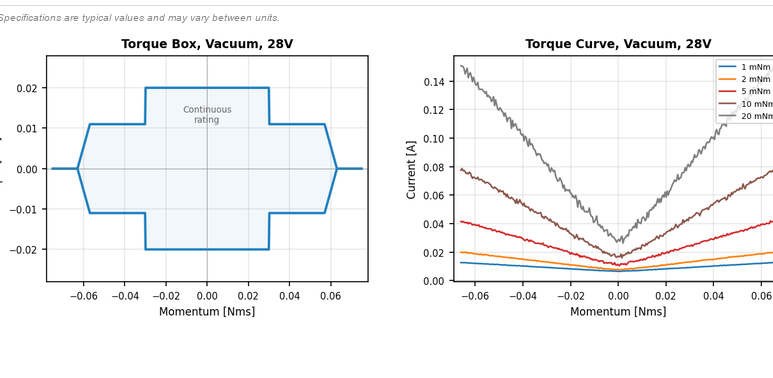

In [7]:
_ = ask('Show me the torque curve for the RW3 0.06')

The datasheet image above comes from the deterministic query→part resolution, not
from the model's tool phrasing — so it's the *right* part's chart every run. (See
notebook `03` for the visual-intent gate that decides when to attach an image.)

---
## 4 · Compound multimodal: an image in, the full pipeline out

*Demo Query 4 — the most capable flow.* Upload a chart crop, and the system:

1. embeds it with **Nova MME** and matches it against the **S3 Vectors** index to
   **identify** which wheel the curve belongs to (image-as-query),
2. finds alternatives at the same momentum + interface,
3. scores them, and
4. compares product photos to flag physical differences.

We attach a ready-made crop from `demo-crops/` (the same ones the live demo uses).
The matched datasheet renders inline.

_Requires: Bedrock + Nova MME + a configured `PARTS_KB_ID` **and** the S3 Vectors
index with `s3vectors:QueryVectors` permission. Without S3 Vectors, image-as-query
degrades to text search (and may name the wrong part — the tool logs a loud
`S3 Vectors image query FAILED` warning). The cell is safe to run regardless; it
just won't identify-by-image without that setup._

crop exists: True → rw_rl_0060_0.06Nms_torque_curve.png


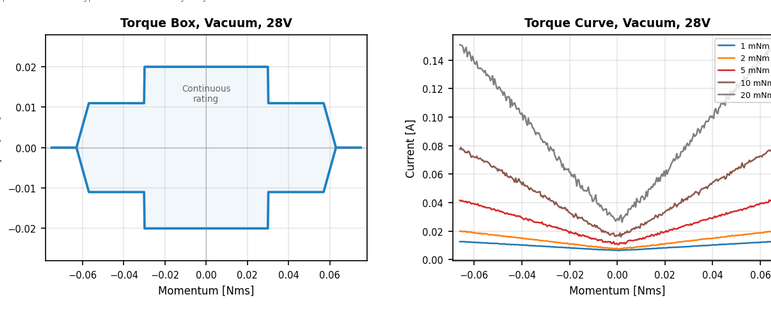

In [8]:
crop = NB_DIR / 'demo-crops' / 'rw_rl_0060_0.06Nms_torque_curve.png'
print('crop exists:', crop.exists(), '→', crop.name)
display(Image(filename=str(crop), width=420))

img_b64 = base64.b64encode(crop.read_bytes()).decode('utf-8') if crop.exists() else None

In [9]:
if img_b64:
    _ = ask(
        'Identify which wheel this torque curve belongs to, then find alternatives '
        'with at least the same momentum and a 28V RS-422 interface, score them '
        'against those requirements, and tell me if any of them look physically '
        'different in the product photos.',
        image_b64=img_b64,
        timeout=300,
    )
else:
    print('demo crop missing — skip this cell')

1. KNOWLEDGE — identify the part from the torque curve image via visual search match and retrieve its specifications
2. CATALOG —

 find alternatives with at least the identified part's momentum and a 28V RS-422 interface
3. EVALUATION — score candidates against momentum and RS-422 requirements and compare physical form factor in product photos

**Routing:** KNOWLEDGE  →  CATALOG  →  EVALUATION

**Errors:** {'specialist': 'system', 'message': 'An error occurred (ServiceUnavailableException) when calling the ConverseStream operation (reached max retries: 4): Bedrock is unable to process your request.'}

## Identification
The torque curve best matches **AnyCompany RW3 0.06 (rw_rl_0060)**. Its visual retrieval score was 0.966, against 0.876 for rw_rl_0400 and 0.852 for rw_rl_1000.

## Spec-fit table
**Requirements used:** momentum ≥ 0.06 Nms, 28 V, RS-422. All parts have the vendor "AnyCompany". Operating temperature was not given as a requirement, so it was compared against the reference.

| Spec | Rule | RW4 0.4 (rw_rl_0400) | RW4 1.0 (rw_rl_1000) | RW 5.0 (rw_rl_5000) |
|---|---|---|---|---|
| Momentum (≥0.06 Nms) | ≥ required | 0.4 – pass | 1.0 – pass | 5.0 – pass |
| Bus voltage (28 V) | match | 28 – pass | 28 – pass | 28 – pass |
| Interface (RS-422) | match | RS-422 / RS-485 – pass | RS-422 / RS-485 – pass | RS-422 / RS-485 – pass |
| Operating temp (ref: -30 to +70 °C) | envelops | pass | pass | pass |
| Max torque (ref 20 mNm) | ≥ reference | 100 – pass | 100 – pass | 150 – pass |
| **Mass (ref 235 g, +20% = 282 g)** | ≤ reference +20% | **755 g – FLAG** | **1400 g – FLAG** | **3000 g – FLAG** |
| Radiation tolerance (ref 20 krad) | ≥ reference | 50 – pass | 50 – pass | 50 – pass |
| Qualification standard | same standard | AnyCompany internal (flight heritage) – pass | same – pass | same – pass |
| Lifecycle / lead time | | Active, 12 wk | Active, 12 wk | Active, 16 wk |
| **Tally** | | 7 pass, 1 flag | 7 pass, 1 flag | 7 pass, 1 flag |

- **Mass flag:** All three candidates exceed the mass tolerance, so none is a drop-in replacement. The tool says the flag needs engineering review.
- **Not covered by the scored rules:** The catalog data from the earlier specialists shows a narrower bus range for all three candidates (22–34 V, against 7.5–36 V for the RW3 0.06). It also shows higher power draw: 2.8 W, 5 W and 20 W, against 1.3 W. The "28 V" match above does not capture either difference.
- **Lifecycle:** All candidates are Active. The earlier catalog pass noted the RW 5.0 has the least flight heritage (first flights in 2026) and a Medium supply-chain risk on its 16-week lead time.

## Supplemental: Visual Analysis
I ran the visual check on all three candidates, because you asked about physical differences. All three look physically different from the RW3 0.06.

| Candidate | Nova MME similarity | Interpretation | Key observed differences |
|---|---|---|---|
| RW4 0.4 | 0.686 | Visually different form factors | The RW3 0.06 has a square frame with four corner through-holes. The RW4 0.4 is a circular ring of bare machined metal with a large open through-bore and a circular bolt pattern. The mounting patterns are geometrically incompatible. |
| RW4 1.0 | 0.659 | Visually different form factors | The RW4 1.0 is a large round drum with a deep rim, a large polished hub and rear stud-type mounting. It could not replace the RW3 0.06 in the same bracket. |
| RW 5.0 | 0.512 | Visually different form factors | The RW 5.0 is the most different. It is a round drum, much larger and deeper, with a wide open bore and several connectors on its side wall. Its mounting method is not clearly visible. |

- **Caveats:** The photos have no scale reference, so sizes are relative. Connector locations could not be confirmed on the RW3 0.06 or the RW4 1.0.
- **Earlier finding corrected:** The earlier specialists reported that no photo was returned for the RW4 0.4 and RW 5.0. Photos were found and analyzed for both.
- **Visual similarity** is a supplemental signal only, not a decision basis.

**Disclaimer:** This is evidence only. It does not recommend or approve any substitution. The engineer decides.

### 4.1 Under the hood — image-as-query against S3 Vectors (inlined)

§4 ran image-as-query through the streaming agent. Here's the **actual retrieval
code** underneath it, reproduced inline so you can see (and run) the mechanism —
this is the body of `retrieve_visual_content`'s image path in `agent/tools.py`.

The key design point: a **managed** Bedrock Knowledge Base can't take an IMAGE as
a query, so image-as-query goes to a **native Amazon S3 Vectors index** instead.
We embed the uploaded image with Nova MME, then `query_vectors` for the nearest
indexed vectors (product photos + cropped datasheet chart regions), and collapse
to the best hit per part.

_Requires: Bedrock + Nova MME, a built S3 Vectors index, and
`s3vectors:QueryVectors` permission. If those aren't set up this cell prints a
clear notice instead of failing — the two-path fallback is the whole point._

In [10]:
import os
REGION = os.environ.get('BEDROCK_REGION', 'us-east-1')
import base64, boto3, json

NOVA_MME_MODEL_ID = 'amazon.nova-2-multimodal-embeddings-v1:0'
S3_VECTOR_BUCKET = os.environ.get('S3_VECTOR_BUCKET', 'skylab-mfg-vectors')
S3_VECTOR_INDEX = os.environ.get('S3_VECTOR_INDEX', 'reaction-wheels-synthetic')

def embed_query_image(image_bytes):
    """Nova MME image embedding (IMAGE_RETRIEVAL), 1024-d — same as indexing."""
    b64 = base64.b64encode(image_bytes).decode('utf-8')
    fmt = 'png' if image_bytes[:8] == b'\x89PNG\r\n\x1a\n' else 'jpeg'
    body = {'taskType': 'SINGLE_EMBEDDING', 'singleEmbeddingParams': {
        'embeddingPurpose': 'IMAGE_RETRIEVAL', 'embeddingDimension': 1024,
        'image': {'detailLevel': 'STANDARD_IMAGE', 'format': fmt,
                  'source': {'bytes': b64}}}}
    br = boto3.client('bedrock-runtime', region_name=REGION)
    r = br.invoke_model(modelId=NOVA_MME_MODEL_ID, body=json.dumps(body),
                        accept='application/json', contentType='application/json')
    return json.loads(r['body'].read())['embeddings'][0]['embedding']

def image_as_query(image_b64, top_k=3):
    """Image-as-query against the native S3 Vectors index. Portable reproduction
    of retrieve_visual_content's image branch (agent/tools.py). Returns best hit
    per part, or a {'note': ...} dict if S3 Vectors isn't available."""
    try:
        emb = embed_query_image(base64.b64decode(image_b64))
        s3v = boto3.client('s3vectors', region_name=REGION)
        fetch_k = max(top_k * 6, 12)  # each part has several vectors; dedupe below
        resp = s3v.query_vectors(
            vectorBucketName=S3_VECTOR_BUCKET, indexName=S3_VECTOR_INDEX,
            queryVector={'float32': emb}, topK=fetch_k,
            returnDistance=True, returnMetadata=True,
        )
        best = {}
        for v in resp.get('vectors', []):
            meta = v.get('metadata', {}) or {}
            pid = meta.get('part_id', '')
            if not pid:
                continue
            sim = 1.0 - v.get('distance', 1.0)  # cosine distance -> similarity
            if pid not in best or sim > best[pid]['score']:
                best[pid] = {'part_id': pid, 'score': sim,
                             'source_file': meta.get('source_file', ''),
                             'name': meta.get('name', '')}
        ranked = sorted(best.values(), key=lambda r: r['score'], reverse=True)
        return {'results': ranked[:top_k], 'retrieval': 's3_vectors',
                'index': f'{S3_VECTOR_BUCKET}/{S3_VECTOR_INDEX}'}
    except Exception as e:
        # The two-path fallback: on ANY failure (no index, no perms, region),
        # signal 'not available' so a caller can fall back to text search. In the
        # real tool this logs a loud warning so a silent wrong-part match can't
        # happen unnoticed.
        return {'note': f'S3 Vectors image-as-query unavailable: {type(e).__name__}: {e}. '
                         f'(index={S3_VECTOR_BUCKET}/{S3_VECTOR_INDEX}) '
                         f'In the app this falls back to text retrieval.'}

if img_b64:
    out = image_as_query(img_b64, top_k=3)
    if out.get('results'):
        print('Image matched these parts (best vector per part):')
        for r in out['results']:
            print(f"  {r['part_id']:12s} score={r['score']:.3f}  {r['source_file']}")
        top = out['results'][0]
        print(f"\nTop match: {top['part_id']} (score {top['score']:.3f}) "
              f"— the uploaded RW3 0.06 chart should resolve to rw_rl_0060.")
    else:
        print(out.get('note', 'no results'))
else:
    print('demo crop missing — skip this cell')

Image matched these parts (best vector per part):
  rw_rl_0060   score=0.966  datasheet_page.png
  rw_rl_0400   score=0.876  datasheet_page.png
  rw_rl_1000   score=0.852  datasheet_page.png

Top match: rw_rl_0060 (score 0.966) — the uploaded RW3 0.06 chart should resolve to rw_rl_0060.


That's the mechanism the agent uses to answer *"which wheel is this chart?"*. The
scores you see are real cosine similarities from the S3 Vectors index; the top
hit is the identified part. (If you got the *unavailable* notice, the index/perms
aren't set up in this environment — the agent would transparently fall back to a
text search, which is exactly why the real tool logs a loud warning when the
image path doesn't run.)

---
## 5 · Draft a formal substitution memo (fully local)

*Demo menu — Evaluation.* The `generate_substitution_memo` tool assembles a
complete **Part Substitution Justification (PSJ)**: reference vs. candidate tables,
a full spec comparison, qualification delta, risk assessment, and a signature
block — as ready-to-review Markdown. This is deterministic (built from catalog
data), so it runs with **no Bedrock access**. We render it inline.

_Requires: nothing beyond the local catalog._

In [11]:
from mei_core.tools import generate_substitution_memo

memo = generate_substitution_memo(
    reference_part_id='RW 5.0',
    candidate_part_id='RW4 1.0',
    rationale='RW 5.0 lead time is a program risk; evaluating the RW4 1.0 as a lower-'
              'momentum alternative for a reduced-slew mission profile.',
)
print('document:', memo['document_id'], '|',
      f"{memo['matches_count']}/{memo['total_fields']} fields match, "
      f"{memo['differences_count']} differ")
display(Markdown(memo['markdown']))

document: PSJ-20261008-191628 | 9/21 fields match, 12 differ


# PART SUBSTITUTION JUSTIFICATION

**Document No:** PSJ-20261008-191628
**Date:** 2026-10-08
**Status:** DRAFT — Pending Engineering Review

---

## 1. Reference Part (being replaced)

| Field | Value |
|-------|-------|
| Name | AnyCompany RW 5.0 |
| Part ID | RW 5.0 |
| Vendor | AnyCompany |
| Qualification Standard | AnyCompany internal (flight heritage qualified) |
| Lifecycle Status | Active |

## 2. Proposed Substitute

| Field | Value |
|-------|-------|
| Name | AnyCompany RW4 1.0 |
| Part ID | RW4 1.0 |
| Vendor | AnyCompany |
| Qualification Standard | AnyCompany internal (flight heritage qualified) |
| Lifecycle Status | Active |

## 3. Justification

RW 5.0 lead time is a program risk; evaluating the RW4 1.0 as a lower-momentum alternative for a reduced-slew mission profile.

## 4. Technical Comparison

**Summary:** 9/21 fields match. 12 differences identified.

| Spec | Reference | Candidate | Verdict |
|------|-----------|-----------|---------|
| category | reaction_wheel | reaction_wheel | Match |
| control_mode | Speed, Torque | Speed, Torque | Match |
| dimensions_mm | 194 x 192 x 57.25 | 148 x 146 x 45 | DIFFERENT |
| heritage | First flights 2026; bearings common with all RW models, 420+ cumulative years across 263 units | 144 units across 2 generations; 670+ cumulative years since 2016 | DIFFERENT |
| interface | RS-422 or Redundant RS-485 | RS-422 or Redundant RS-485 | Match |
| lifecycle | {'lifecycle_status': 'Active', 'production_status': 'Full production', 'estimated_years_to_eol': '10+', 'last_time_buy': 'Not announced', 'typical_lead_time_weeks': 16, 'lead_time_risk': 'Medium', 'forecast_demand_trend': 'Increasing', 'mtbf_hours': None, 'fit_rate': None, 'reliability_prediction_basis': 'Flight heritage (420+ cumulative years, 263 units); bearings design common across all models', 'weibull_shape_beta': None, 'bathtub_region': 'Early useful life (first flights 2026)', 'recommended_screening': 'Standard flight acceptance'} | {'lifecycle_status': 'Active', 'production_status': 'Full production', 'estimated_years_to_eol': '10+', 'last_time_buy': 'Not announced', 'typical_lead_time_weeks': 12, 'lead_time_risk': 'Low', 'forecast_demand_trend': 'Stable', 'mtbf_hours': None, 'fit_rate': None, 'reliability_prediction_basis': 'Flight heritage (670+ cumulative years, 144 units, 2 generations since 2016)', 'weibull_shape_beta': None, 'bathtub_region': 'Useful life (mature, well-established)', 'recommended_screening': 'Standard flight acceptance'} | DIFFERENT |
| mass_g | 3000 | 1400 | DIFFERENT |
| max_torque_mnm | 150 | 100 | DIFFERENT |
| model | RW-5.0 | RW4-1.0 | DIFFERENT |
| momentum_storage_nms | 5.0 | 1.0 | DIFFERENT |
| name | AnyCompany RW 5.0 | AnyCompany RW4 1.0 | DIFFERENT |
| operating_temp_c | -30 to +70 | -30 to +70 | Match |
| part_id | rw_rl_5000 | rw_rl_1000 | DIFFERENT |
| power_w | 20 | 5 | DIFFERENT |
| qual_standard | AnyCompany internal (flight heritage qualified) | AnyCompany internal (flight heritage qualified) | Match |
| radiation_tolerance_krad | 50 | 50 | Match |
| shock_g | 1200 | — | DIFFERENT |
| vendor | AnyCompany | AnyCompany | Match |
| vibration_grms | 14.1 | 20.0 | DIFFERENT |
| voltage_range_v | 22 to 34 | 22 to 34 | Match |
| voltage_v | 28 | 28 | Match |


## 5. Key Differences (require engineering review)

- **dimensions_mm**: Reference = `194 x 192 x 57.25` → Candidate = `148 x 146 x 45`
- **heritage**: Reference = `First flights 2026; bearings common with all RW models, 420+ cumulative years across 263 units` → Candidate = `144 units across 2 generations; 670+ cumulative years since 2016`
- **lifecycle**: Reference = `{'lifecycle_status': 'Active', 'production_status': 'Full production', 'estimated_years_to_eol': '10+', 'last_time_buy': 'Not announced', 'typical_lead_time_weeks': 16, 'lead_time_risk': 'Medium', 'forecast_demand_trend': 'Increasing', 'mtbf_hours': None, 'fit_rate': None, 'reliability_prediction_basis': 'Flight heritage (420+ cumulative years, 263 units); bearings design common across all models', 'weibull_shape_beta': None, 'bathtub_region': 'Early useful life (first flights 2026)', 'recommended_screening': 'Standard flight acceptance'}` → Candidate = `{'lifecycle_status': 'Active', 'production_status': 'Full production', 'estimated_years_to_eol': '10+', 'last_time_buy': 'Not announced', 'typical_lead_time_weeks': 12, 'lead_time_risk': 'Low', 'forecast_demand_trend': 'Stable', 'mtbf_hours': None, 'fit_rate': None, 'reliability_prediction_basis': 'Flight heritage (670+ cumulative years, 144 units, 2 generations since 2016)', 'weibull_shape_beta': None, 'bathtub_region': 'Useful life (mature, well-established)', 'recommended_screening': 'Standard flight acceptance'}`
- **mass_g**: Reference = `3000` → Candidate = `1400`
- **max_torque_mnm**: Reference = `150` → Candidate = `100`
- **model**: Reference = `RW-5.0` → Candidate = `RW4-1.0`
- **momentum_storage_nms**: Reference = `5.0` → Candidate = `1.0`
- **name**: Reference = `AnyCompany RW 5.0` → Candidate = `AnyCompany RW4 1.0`
- **part_id**: Reference = `rw_rl_5000` → Candidate = `rw_rl_1000`
- **power_w**: Reference = `20` → Candidate = `5`
- **shock_g**: Reference = `1200` → Candidate = `—`
- **vibration_grms**: Reference = `14.1` → Candidate = `20.0`

## 6. Qualification Delta

- Reference standard: AnyCompany internal (flight heritage qualified)
- Candidate standard: AnyCompany internal (flight heritage qualified)
- Standards match.

## 7. Risk Assessment

- Reference lifecycle: Active
- Candidate lifecycle: Active
- Candidate lead time: 12 weeks
- Candidate lead time risk: Low

## 8. Required Approvals

| Role | Signature | Date |
|------|-----------|------|
| Lead Systems Engineer | _______________ | _______ |
| Quality Assurance Manager | _______________ | _______ |
| Program Manager (if cost impact > $10K) | _______________ | _______ |

## 9. Applicable Standards

- AS9100 Rev D Section 8.5.6 — Control of Changes
- AS9100 Rev D Section 8.4 — Control of Externally Provided Processes

## 10. References

- AnyCompany RW 5.0 datasheet (AnyCompany)
- AnyCompany RW4 1.0 datasheet (AnyCompany)
- Interface Control Documents (ICDs) for both parts

---

*This document was generated as a DRAFT for engineering review. It does not constitute approval of the substitution. The signing engineer accepts responsibility for the technical decision.*


---
## 6 · Visual similarity: Nova MME score + Claude Vision analysis

*Demo menu — the two-model visual signal.* `visual_similarity_score` embeds both
parts' product photos with **Nova MME** for a quantitative cosine similarity, then
asks **Claude Vision** for concrete physical differences (housing, mounting,
connector, form factor). It's a supplemental signal — never the decision basis.

We display both photos, then the score and the vision analysis.

_Requires: Bedrock + Nova MME. If Claude Vision is throttled/unavailable the Nova
MME score still returns, with a note in `physical_analysis`._

**A: RW3 0.06**  (`rw_rl_0060`)

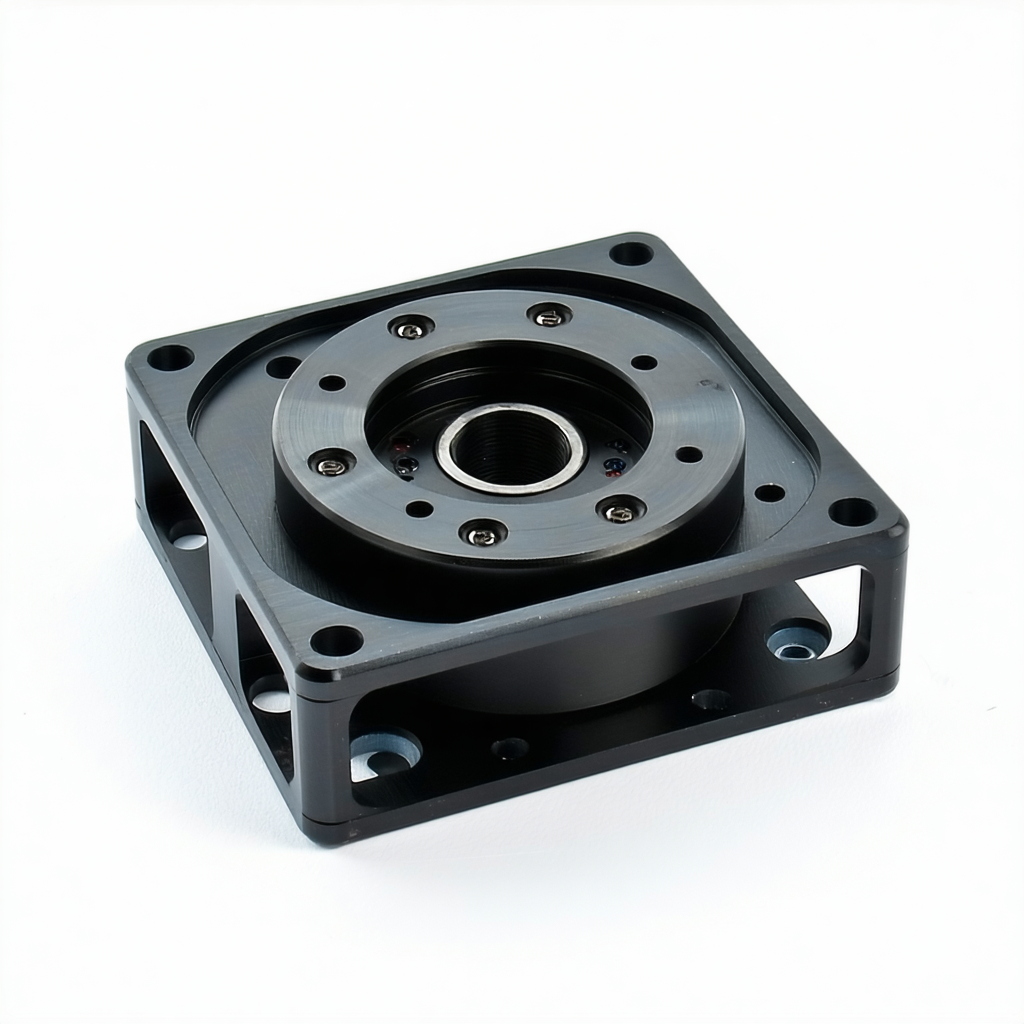

**B: RW 5.0**  (`rw_rl_5000`)

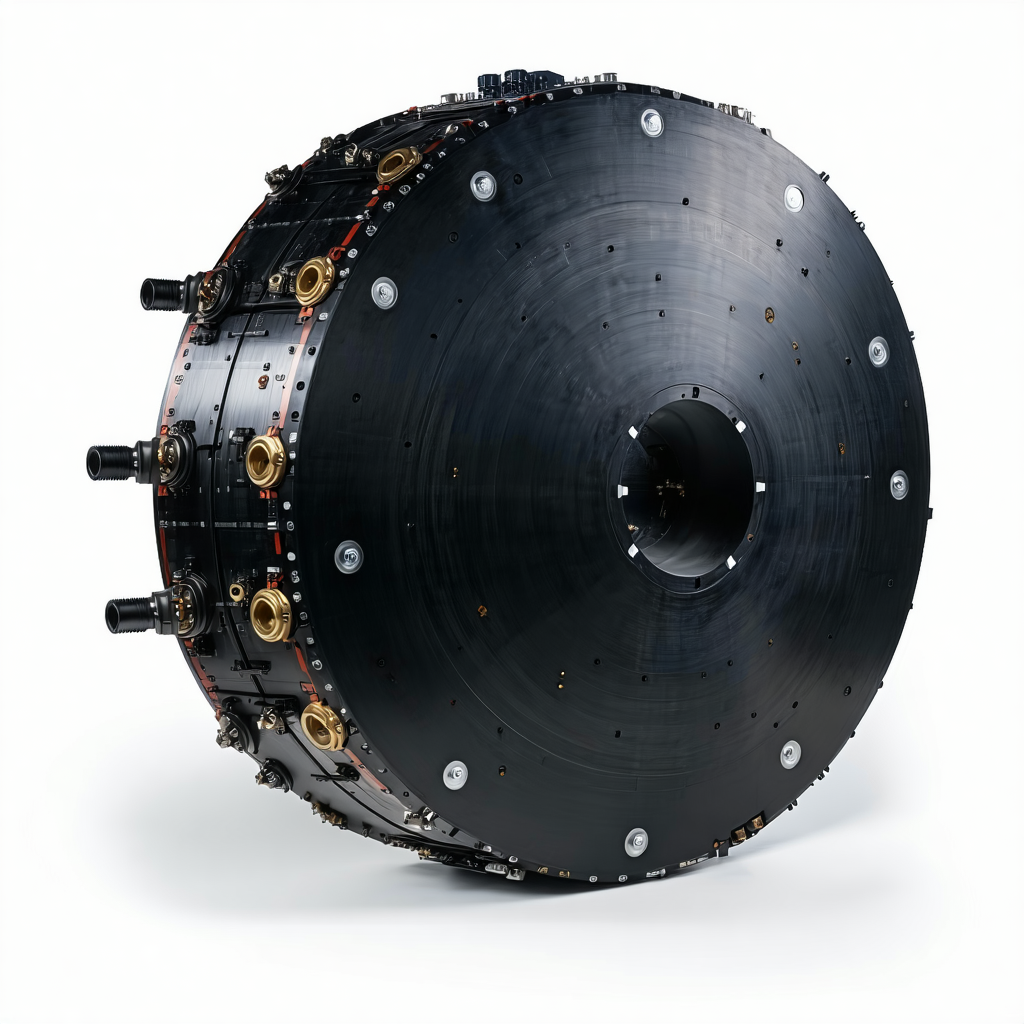

In [12]:
from mei_core.tools import visual_similarity_score, _resolve_part_id

a, b = 'RW3 0.06', 'RW 5.0'
for label, name in [('A', a), ('B', b)]:
    pid = _resolve_part_id(name)
    for ext in ('png', 'jpg', 'jpeg'):
        p = Path(PARTS_DATA_DIR) / pid / f'photo.{ext}'
        if p.exists():
            display(Markdown(f'**{label}: {name}**  (`{pid}`)'))
            display(Image(filename=str(p), width=300))
            break

In [13]:
vs = visual_similarity_score(a, b)
if 'error' in vs:
    print('error:', vs['error'])
else:
    display(Markdown(
        f"**Nova MME similarity:** {vs['visual_similarity']}  "
        f"— _{vs['interpretation']}_\n\n"
        f"**Models:** {', '.join(vs['models_used'])}\n\n"
        f"**Claude Vision — physical differences:**\n\n{vs['physical_analysis']}"
    ))

**Nova MME similarity:** 0.5116  — _Visually different form factors_

**Models:** amazon.nova-2-multimodal-embeddings-v1:0 (quantitative similarity), claude-sonnet-5-5 (physical difference analysis)

**Claude Vision — physical differences:**

**Observations from the two images (no scale reference is given, so sizes are relative only):**

- **Housing shape and geometry**
  - **RW3 0.06 (Image 1):** The housing is a square, flat-profile frame with rounded corners. It is machined from black anodized metal. The sides are open, with window-like cutouts that expose a cylindrical rotor body inside. The overall height is small relative to the footprint.
  - **RW 5.0 (Image 2):** The housing is a fully round, drum- or disc-shaped cylinder with a closed circular face. Its diameter is much larger than its depth, and the visible face is far larger than the entire RW3 0.06 unit.

- **Relative size**
  - The RW 5.0 appears substantially larger and bulkier than the RW3 0.06. Its disc face looks several times wider than the RW3 0.06's square footprint. The true ratio can't be determined without a scale reference.

- **Mounting interface**
  - **RW3 0.06:** Four large through-holes sit at the corners of the square flange. There are additional smaller holes on the top plate and on the base plate visible through the side openings. The top face has a central circular hub with a bored center, ringed by small screws and holes. This looks like a standard square corner-bolt pattern.
  - **RW 5.0:** No corner flange or square bolt pattern is visible. Instead, about 8–10 flat-head screws or washers are spaced around the perimeter of the circular face, and many small scattered holes are visible across the surface. The rim has a large central bore. Any mounting pattern would be circular, not square.

- **Connector location and type**
  - **RW3 0.06:** No electrical connector is clearly visible from this angle. Small openings in the side frame may hold wiring or connector access, but I can't confirm this.
  - **RW 5.0:** Several black cylindrical fittings project outward from the side of the housing, along with gold or brass-colored circular ports and exposed PCB or electronics edges around the rim. These are on the curved side wall, not on the flat face.

- **Central feature**
  - Both units have a central bore. In the RW3 0.06 it is small, threaded, and ringed by a bearing-like metal sleeve. In the RW 5.0 it is a large open through-hole, proportionally much bigger.

- **

---
## 7 · Free exploration — the full query menu

Everything above was a *specific* flow. The graph handles a broad menu of
questions; here's the catalog of demo prompts grouped by the specialist each
routes to. Uncomment any line (or edit the loop) to run it.

_Requires: Bedrock._

In [14]:
QUERY_MENU = {
    'CATALOG (discovery)': [
        'Which AnyCompany wheels are compatible with a 5V bus?',
        'Find reaction wheels with at least 1.0 Nms momentum and RS-422.',
        'What are the lightest wheels in the catalog?',
        'Show me all wheels with radiation tolerance above 30 krad.',
        'Which wheels use the ASYNC interface?',
    ],
    'EVALUATION (score / compare / memo)': [
        'Score the RW 0.03 against the RW3 0.06 for my nanosatellite.',
        'Compare the RW4 0.4 vs RW4 1.0 for a 12U CubeSat.',
        'Draft a substitution memo for the RW4 1.0 replacing the RW 5.0.',
        'Can the RW 0.03 substitute for the RW3 0.06? I need 0.05 Nms on a 28V RS-422 bus.',
    ],
    'KNOWLEDGE (detail / web / visual)': [
        "What's the flight heritage of the RW4 1.0?",
        'What does the ICD say about the RW3 0.06 command interface?',
        "What's the radiation tolerance for the RW 5.0?",
        "What's the current lead time for the RW4 0.4? Any supply constraints?",
        'Show me the torque curve for the RW4 0.4.',
        'Pull the datasheet page for the RW 5.0.',
    ],
    'CHAINS (complex, multi-specialist)': [
        'The RW3 0.06 might be going EOL. Check status, find 28V RS-422 alternatives, '
        'and score them against 0.06 Nms minimum.',
        'I need a wheel for a 5V nanosatellite. What is available, and how do they '
        'compare to the RW 0.03?',
        'Check the market status of the RW 0.003, then find alternatives if it is at '
        'risk, and score them for a 7V I2C application.',
    ],
}

for group, qs in QUERY_MENU.items():
    print(f'\n### {group}')
    for qq in qs:
        print('  -', qq)


### CATALOG (discovery)
  - Which AnyCompany wheels are compatible with a 5V bus?
  - Find reaction wheels with at least 1.0 Nms momentum and RS-422.
  - What are the lightest wheels in the catalog?
  - Show me all wheels with radiation tolerance above 30 krad.
  - Which wheels use the ASYNC interface?

### EVALUATION (score / compare / memo)
  - Score the RW 0.03 against the RW3 0.06 for my nanosatellite.
  - Compare the RW4 0.4 vs RW4 1.0 for a 12U CubeSat.
  - Draft a substitution memo for the RW4 1.0 replacing the RW 5.0.
  - Can the RW 0.03 substitute for the RW3 0.06? I need 0.05 Nms on a 28V RS-422 bus.

### KNOWLEDGE (detail / web / visual)
  - What's the flight heritage of the RW4 1.0?
  - What does the ICD say about the RW3 0.06 command interface?
  - What's the radiation tolerance for the RW 5.0?
  - What's the current lead time for the RW4 0.4? Any supply constraints?
  - Show me the torque curve for the RW4 0.4.
  - Pull the datasheet page for the RW 5.0.

### CHAINS (com

In [15]:
# Pick any prompt from the menu above and run it live:
_ = ask('Compare the RW4 0.4 vs RW4 1.0 for a 12U CubeSat.')

1. EVALUATION — compare RW4 0.4 vs RW4 1.0 against 12U CubeSat requirements

**Routing:** EVALUATION

# RW4 0.4 vs RW4 1.0: Spec-Fit Evaluation

**Reference:** AnyCompany RW4 0.4 (`rw_rl_0400`)
**Candidate:** AnyCompany RW4 1.0 (`rw_rl_1000`)

The tool returned no separate structured vendor field. The vendor name above comes from the catalog display names only.

You gave no numeric requirements for the 12U CubeSat, so the tool compared the candidate against the reference's own values.

| Spec | Reference (0.4) | Candidate (1.0) | Status |
|---|---|---|---|
| Momentum storage (Nm·s) | 0.4 | 1.0 | Pass |
| Bus voltage (V) | 28 | 28 | Pass |
| Interface | RS-422 or Redundant RS-485 | RS-422 or Redundant RS-485 | Pass |
| Operating temp (°C) | -30 to +70 | -30 to +70 | Pass |
| Max torque (mN·m) | 100 | 100 | Pass |
| **Mass (g)** | 755 | **1400** | **Flag** (limit is 906 g, which is the reference +20%) |
| Radiation tolerance (krad) | 50 | 50 | Pass |
| Qualification standard | AnyCompany internal (flight heritage qualified) | Same | Pass |

**Result:** 7 of 8 specs pass and 1 is flagged. The tool's summary says it is not a drop-in replacement.

**Flag:**
- **Mass:** The 1.0 is 645 g (about 85%) heavier than the 0.4. This matters for a 12U mass budget and for the center of mass.

**Lifecycle and supply chain:** Both parts are Active. The candidate's lead time is 12 weeks. No lifecycle flags were raised.

## Supplemental: Visual Analysis
- **Nova MME similarity:** 0.6726. The tool interprets this as "visually different form factors."
- **RW4 0.4:** A wide, flat annular ring with an open center. It has a bolt ring on the outer flange.
- **RW4 1.0:** A deep, dark drum-like cylinder with a closed web plate and a central hub. It has rear threaded studs and no outer bolt ring.
- **Interchangeability:** The photos suggest different mounting envelopes and attachment schemes, so the 1.0 likely can't use the same bracket.
- **Limits:** The photos have no scale reference, and no connector is clearly visible in either. Confirm dimensions and connector placement against the datasheets or ICDs.

## Items for the engineer
- The spec-fit tool doesn't check physical envelope, depth or mounting pattern. Check these against the 12U allocation.
- Your actual momentum, torque, mass and volume requirements weren't supplied. Re-run the comparison with them if you want it checked against your budget and not the reference's values.
- The 1.0 passes on momentum only because it exceeds the 0.4. Whether it suits your mission depends on your real requirement, and so does the extra 0.6 Nm·s of capacity.

*This is evidence only. It is not a recommendation or approval of a substitution. The engineer decides.*

## Recap

In one notebook you've driven the entire demo surface: exhaustive discovery, the
chained EOL→find→score headline flow with live web grounding, a text question that
returns a datasheet chart, the compound **image-in** multimodal pipeline, a formal
substitution memo, the two-model visual-similarity signal, and the full free-
exploration menu — all through the same `ask()` helper that wraps the real
streaming orchestration, with answers and images rendered inline.

The capability map, if you're presenting it:

| Value | Shown by |
|---|---|
| Guaranteed-complete discovery | §1 exhaustive filter |
| Autonomous multi-step reasoning | §2 three-specialist chain |
| Live market grounding | §2 web search |
| Text → visual retrieval | §3 inline datasheet |
| Image-as-query (Nova MME + S3 Vectors) | §4 chart upload → identify |
| Compound multimodal pipeline | §4 identify → find → score → compare |
| Auditable formal documents | §5 PSJ memo |
| Two-model visual analysis | §6 Nova MME + Claude Vision |
| Breadth across query types | §7 menu |

For the mechanics behind any of this, see
[`01`](01_multi_agent_graph_walkthrough.ipynb) (the graph),
[`02`](02_specialist_tools_deep_dive.ipynb) (the tools), and
[`03`](03_streaming_and_gateway.ipynb) (streaming + Gateway).